# Análisis de Diagramas Color-Color con IGAPS (óptico)+Allwise

Este notebook permite visualizar diagramas color-color utilizando datos combinados de IGAPS y ALLWISE. Además, permite dibujar, mover y eliminar líneas en los gráficos, y calcular sus pendientes e interceptos.

In [1]:
%matplotlib widget
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, NullFormatter
from IPython.display import display
import ipywidgets as widgets

# Cargar datos
df = pd.read_csv("../Class_wise_v4/Halpha_emitter_wise_group4-simbad.csv")
print("Number of objects:", len(df))

# Crear nueva columna con agrupaciones específicas
df['grouped_class'] = np.select(
    [df['main_type'].str.contains('YSO|TTauri')],
    ['YSO_TTauri_Group'],
    default=df['main_type']
)

# Definir parámetros visuales para 11 clases
unique_classes = sorted(df['grouped_class'].unique())  # Ordenar para consistencia

# Configuración especial para PlanetaryNeb y PlanetaryNeb_Candidate
marker_dict = {}
color_dict = {}
zorder_dict = {}
class_counter = 0

# Listas base para las otras 9 clases
base_markers = ['o', 's', '^', '*', 'P', 'X', 'h', 'H', 'p', 'd', '8']
base_colors = [
    '#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEEAD',
    '#D4A5A5', '#88D8B0', '#FF9999', '#9999FF', '#FFD700',
    '#C0C0C0'
]

for cls in unique_classes:
    if 'PlanetaryNeb' in cls:
        # Mismo marcador tipo diamante para ambas clases
        marker_dict[cls] = 'D'
        # Colores diferentes y zorder prioritario
        if 'Candidate' in cls:
            color_dict[cls] = '#6A0DAD'  # Púrpura oscuro
            zorder_dict[cls] = 100        # Máxima prioridad
        else:
            color_dict[cls] = '#7BC8F6'    # Azul claro
            zorder_dict[cls] = 99         # Alta prioridad
    else:
        # Asignación para otras clases
        marker_dict[cls] = base_markers[class_counter]
        color_dict[cls] = base_colors[class_counter]
        zorder_dict[cls] = 10 + class_counter  # Prioridad decreciente
        class_counter += 1

# Función para calcular pendiente e intercepto
def calculate_slope_intercept(x1, y1, x2, y2):
    if x1 == x2:
        return np.inf, np.nan
    m = (y2 - y1) / (x2 - x1)
    b = y1 - m * x1
    return m, b

# Función para manejar eventos interactivos
def on_click_factory(ax, text_area, delete_button):
    points = []
    line_count = 0
    lines = []
    selected_line = None
    selected_point_index = None
    dragging = False

    def on_click(event):
        nonlocal line_count, selected_line, selected_point_index, dragging
        if event.inaxes == ax:
            if selected_line is not None and selected_point_index is not None:
                dragging = True
            else:
                points.append((event.xdata, event.ydata))
                if len(points) == 2:
                    x1, y1 = points[0]
                    x2, y2 = points[1]
                    m, b = calculate_slope_intercept(x1, y1, x2, y2)
                    line_count += 1
                    line_label = f'Linea{line_count}'
                    line, = ax.plot([x1, x2], [y1, y2], marker='o', color='black', picker=5)
                    line.set_label(line_label)
                    lines.append(line)
                    ax.text((x1 + x2)/2, (y1 + y2)/2, line_label, 
                           fontsize=10, color='black', ha='center', zorder=150)
                    plt.draw()
                    text_area.value += f'{line_label} = Pendiente: {m:.4f}, Intercepto: {b:.4f}\n'
                    points.clear()

    def on_pick(event):
        nonlocal selected_line, selected_point_index
        artist = event.artist
        if artist in lines:
            if selected_line is artist:
                selected_line.set_color('black')
                selected_line = None
                selected_point_index = None
            else:
                if selected_line is not None:
                    selected_line.set_color('black')
                selected_line = artist
                selected_point_index = event.ind[0]
                artist.set_color('red')
            plt.draw()

    def on_motion(event):
        nonlocal dragging, selected_line, selected_point_index
        if dragging and selected_line is not None and selected_point_index is not None:
            if event.inaxes == ax:
                xdata, ydata = selected_line.get_xdata(), selected_line.get_ydata()
                xdata[selected_point_index] = event.xdata
                ydata[selected_point_index] = event.ydata
                selected_line.set_xdata(xdata)
                selected_line.set_ydata(ydata)
                plt.draw()

    def on_release(event):
        nonlocal dragging, selected_line, selected_point_index
        if dragging and selected_line is not None and selected_point_index is not None:
            xdata, ydata = selected_line.get_xdata(), selected_line.get_ydata()
            x1, y1 = xdata[0], ydata[0]
            x2, y2 = xdata[1], ydata[1]
            m, b = calculate_slope_intercept(x1, y1, x2, y2)
            line_label = selected_line.get_label()
            text_area.value += f'{line_label} (Actualizada) = Pendiente: {m:.4f}, Intercepto: {b:.4f}\n'
            dragging = False

    def on_delete(event):
        nonlocal selected_line
        if selected_line is not None:
            for text in ax.texts:
                if text.get_text() == selected_line.get_label():
                    text.remove()
            selected_line.remove()
            lines.remove(selected_line)
            text_area.value += f'{selected_line.get_label()} (Eliminada)\n'
            plt.draw()
            selected_line = None

    delete_button.on_click(on_delete)
    return on_click, on_pick, on_motion, on_release

def plot_color_color_diagram(pair):
    ((x1, y1), (x2, y2)) = pair
    fig, ax = plt.subplots(figsize=(10, 7), dpi=100)
    
    # Dibujar todas las clases en orden específico
    for cls in unique_classes:
        group_data = df[df['grouped_class'] == cls]
        ax.scatter(
            group_data[x1] - group_data[y1],
            group_data[x2] - group_data[y2],
            c=color_dict[cls],
            s=120 if 'PlanetaryNeb' in cls else 60,  # Tamaño mayor para PlanetaryNeb
            marker=marker_dict[cls],
            edgecolors='k',
            linewidth=0.8 if 'PlanetaryNeb' in cls else 0.4,
            label=cls,
            alpha=0.9,
            zorder=zorder_dict[cls]
        )

    # Configuración de ejes mejorada
    ax.set_xlabel(f"{x1} - {y1}", fontsize=14, fontweight='bold', labelpad=12)
    ax.set_ylabel(f"{x2} - {y2}", fontsize=14, fontweight='bold', labelpad=12)
    ax.tick_params(axis='both', which='major', labelsize=12, width=1.5)
    
    # Configuración de grid y ticks
    ax.grid(True, linestyle=':', color='gray', alpha=0.7, zorder=0)
    ax.xaxis.set_minor_locator(MultipleLocator(0.2))
    ax.yaxis.set_minor_locator(MultipleLocator(0.2))
    ax.xaxis.set_minor_formatter(NullFormatter())
    ax.yaxis.set_minor_formatter(NullFormatter())

    # Leyenda profesional
    legend = ax.legend(
        title="Clasificación de Objetos",
        title_fontsize=13,
        fontsize=11,
        loc='upper left',
        bbox_to_anchor=(1.05, 1),
        borderaxespad=0.8,
        frameon=True,
        framealpha=0.95,
        shadow=True,
        facecolor='#F5F5F5',
        edgecolor='#404040',
        ncol=1
    )
    legend.get_title().set_color('#2A2A2A')

    # Widgets interactivos
    text_area = widgets.Textarea(
        value='',
        placeholder='Resultados de análisis de líneas...',
        description='Datos:',
        layout=widgets.Layout(width='100%', height='150px'),
        style={'description_width': 'initial'}
    )
    
    delete_btn = widgets.Button(
        description='Eliminar línea seleccionada',
        button_style='danger',
        icon='trash',
        layout=widgets.Layout(width='250px', height='35px')
    )
    
    display(widgets.VBox([text_area, delete_btn]))

    # Conectar eventos
    on_click, on_pick, on_motion, on_release = on_click_factory(ax, text_area, delete_btn)
    fig.canvas.mpl_connect('button_press_event', on_click)
    fig.canvas.mpl_connect('pick_event', on_pick)
    fig.canvas.mpl_connect('motion_notify_event', on_motion)
    fig.canvas.mpl_connect('button_release_event', on_release)

    plt.tight_layout()
    plt.show()

Number of objects: 182


## Ejemplo de Uso

Para utilizar la función y crear los gráficos de los pares específicos, ejecuta las siguientes celdas:

```python
plot_color_color_diagram((('W2mag', 'r_PStotal'), ('J0378_PStotal', 'J0430_PStotal')))
plot_color_color_diagram((('J0395_PStotal', 'J0430_PStotal'), ('W2mag', 'i_PStotal')))
plot_color_color_diagram((('i_PStotal', 'z_PStotal'), ('W2mag', 'z_PStotal')))
plot_color_color_diagram((('u_PStotal', 'J0430_PStotal'), ('W1mag', 'W2mag')))
plot_color_color_diagram((('g_PStotal', 'u_PStotal'), ('W1mag', 'i_PStotal')))
plot_color_color_diagram((('W2mag', 'g_PStotal'), ('g_PStotal', 'J0378_PStotal')))
plot_color_color_diagram((('J0430_PStotal', 'J0515_PStotal'), ('i_PStotal', 'J0861_PStotal')))
plot_color_color_diagram((('W1mag', 'z_PStotal'), ('z_PStotal', 'J0660_PStotal')))
plot_color_color_diagram((('W1mag', 'r_PStotal'), ('r_PStotal', 'J0378_PStotal')))

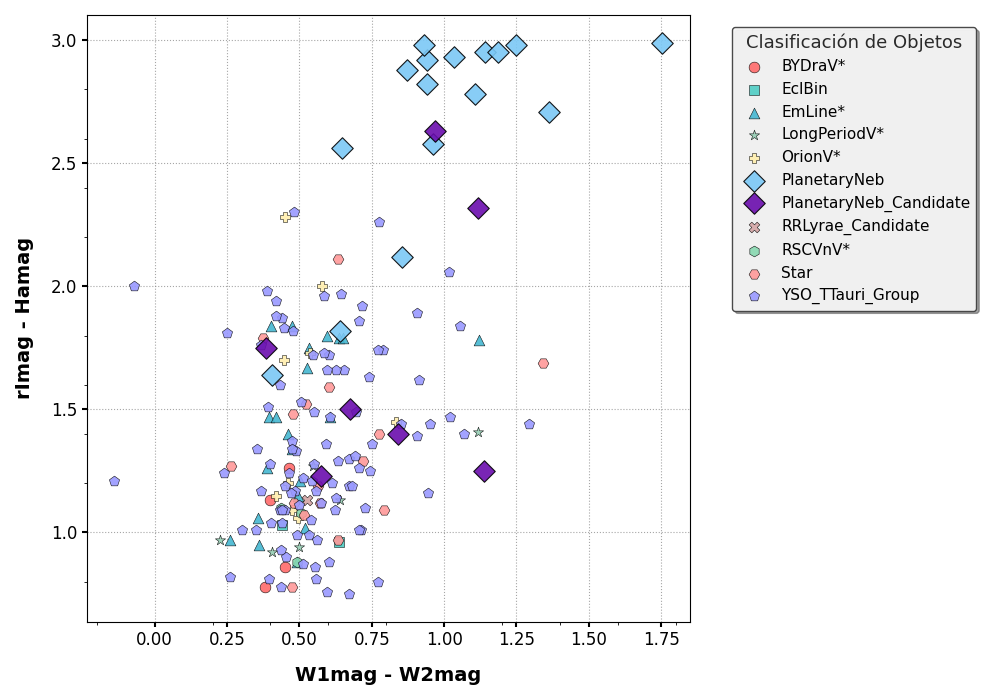

In [2]:
plot_color_color_diagram((("W1mag", "W2mag"), ("rImag", "Hamag")))

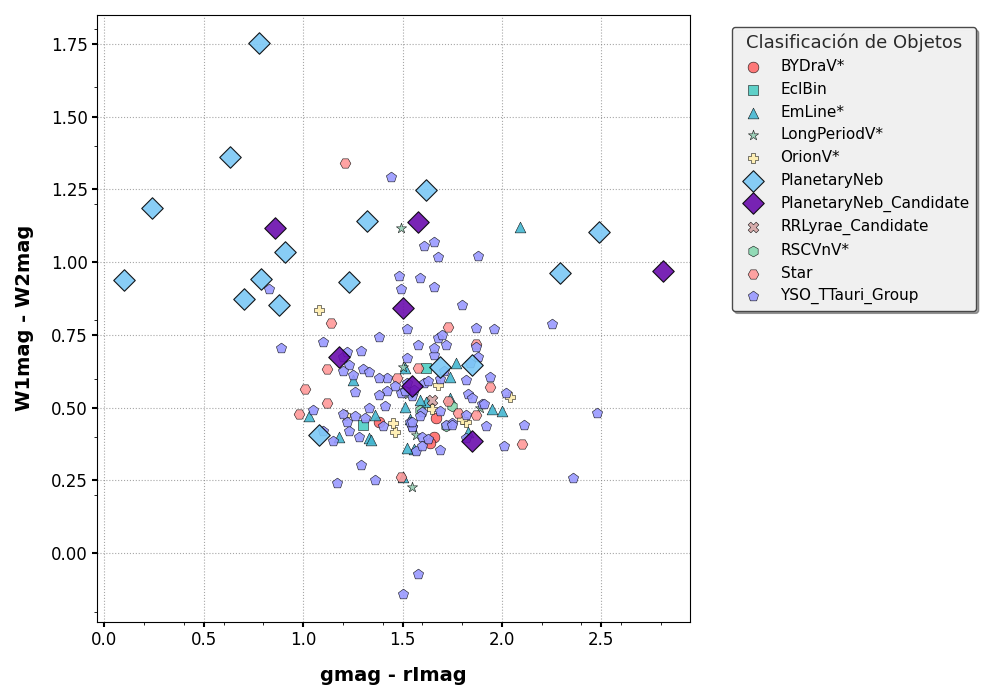

In [3]:
plot_color_color_diagram((('gmag', 'rImag'), ("W1mag", "W2mag")))

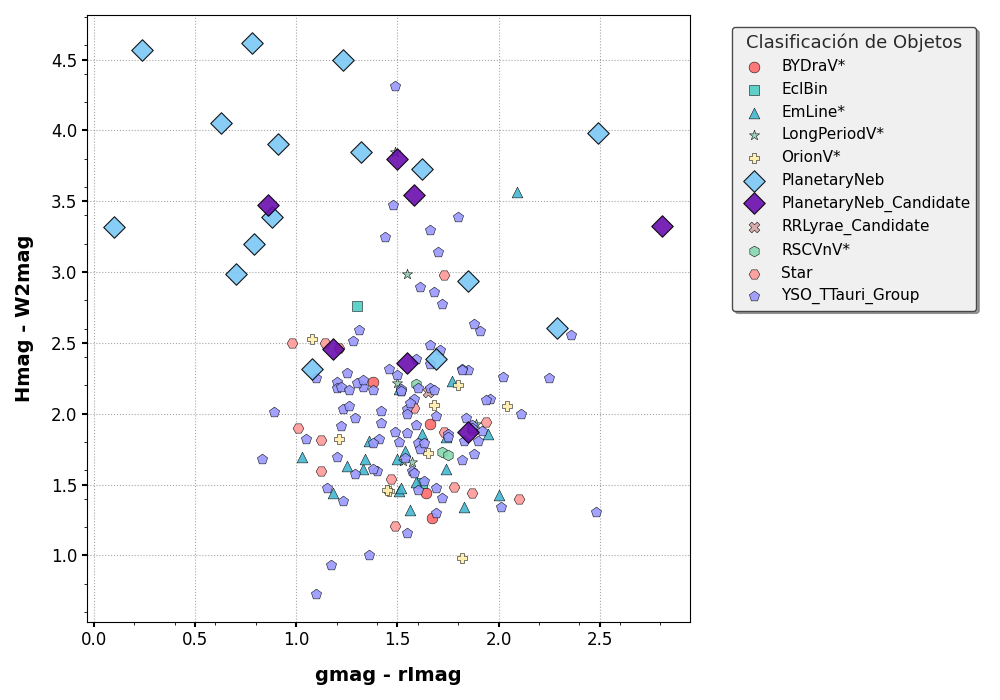

In [4]:
plot_color_color_diagram((('gmag', 'rImag'), ('Hmag', 'W2mag')))

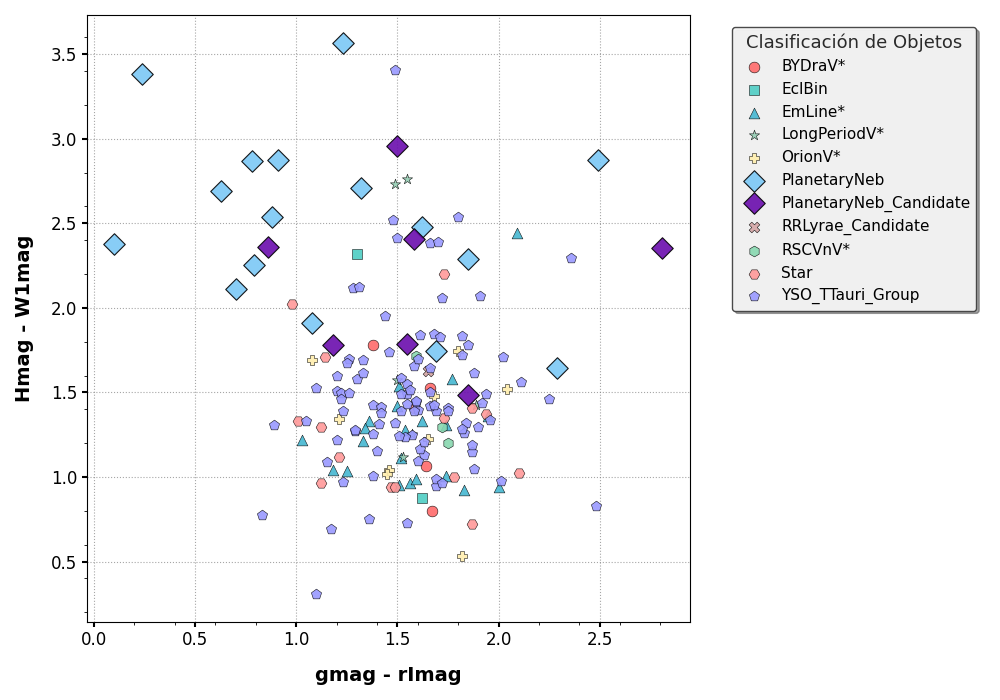

In [5]:
plot_color_color_diagram((('gmag', 'rImag'), ('Hmag', 'W1mag')))

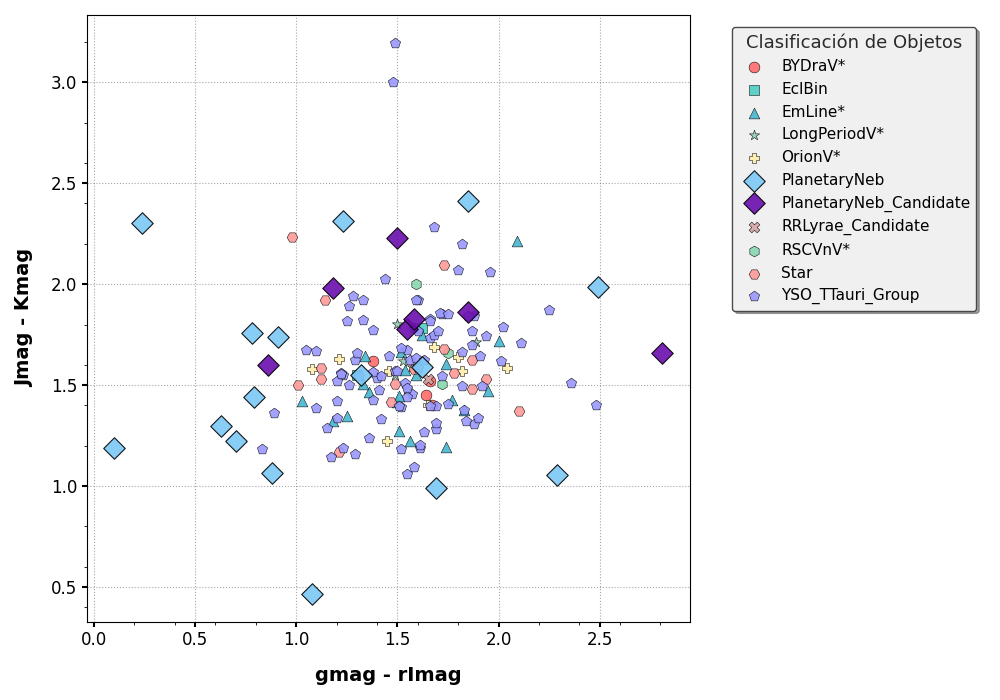

In [6]:
plot_color_color_diagram((('gmag', 'rImag'), ('Jmag', 'Kmag')))

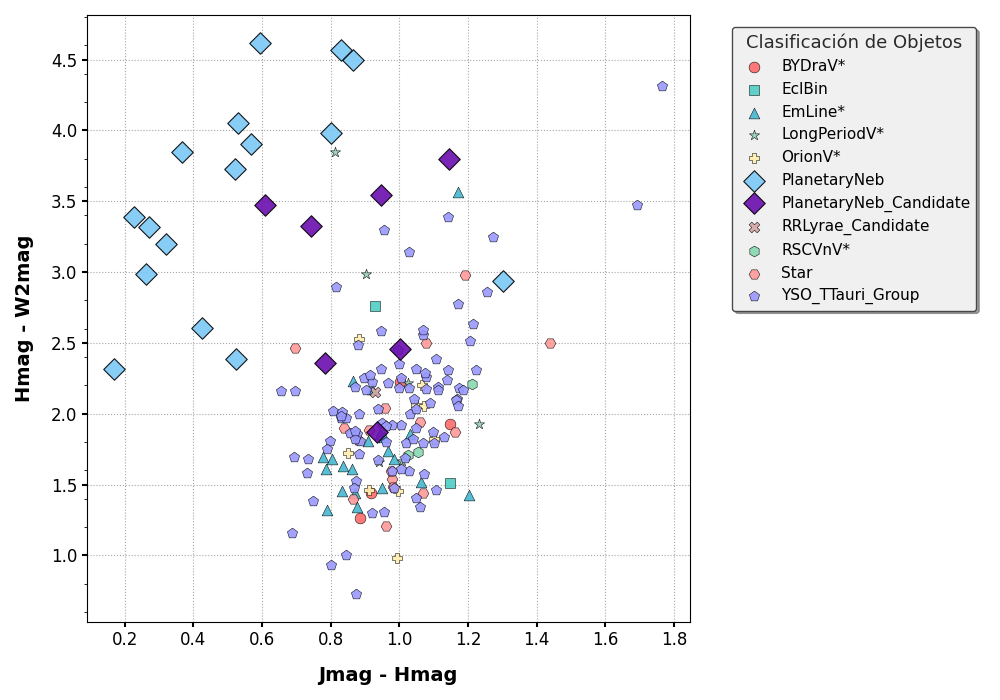

In [7]:
plot_color_color_diagram((('Jmag', 'Hmag'), ('Hmag', 'W2mag')))

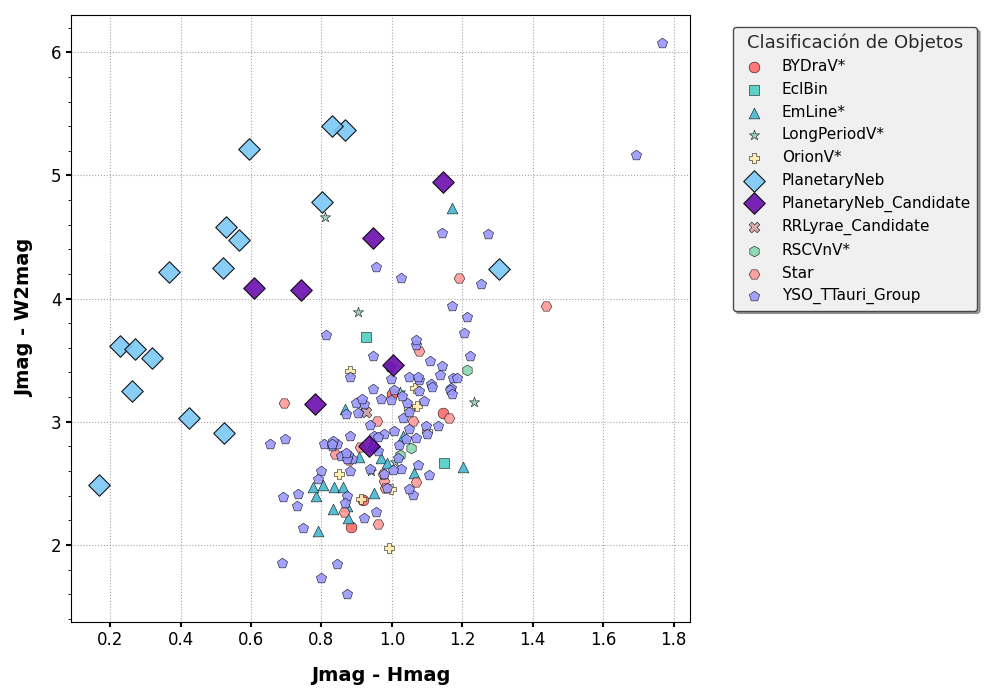

In [8]:
plot_color_color_diagram((('Jmag', 'Hmag'), ('Jmag', 'W2mag')))

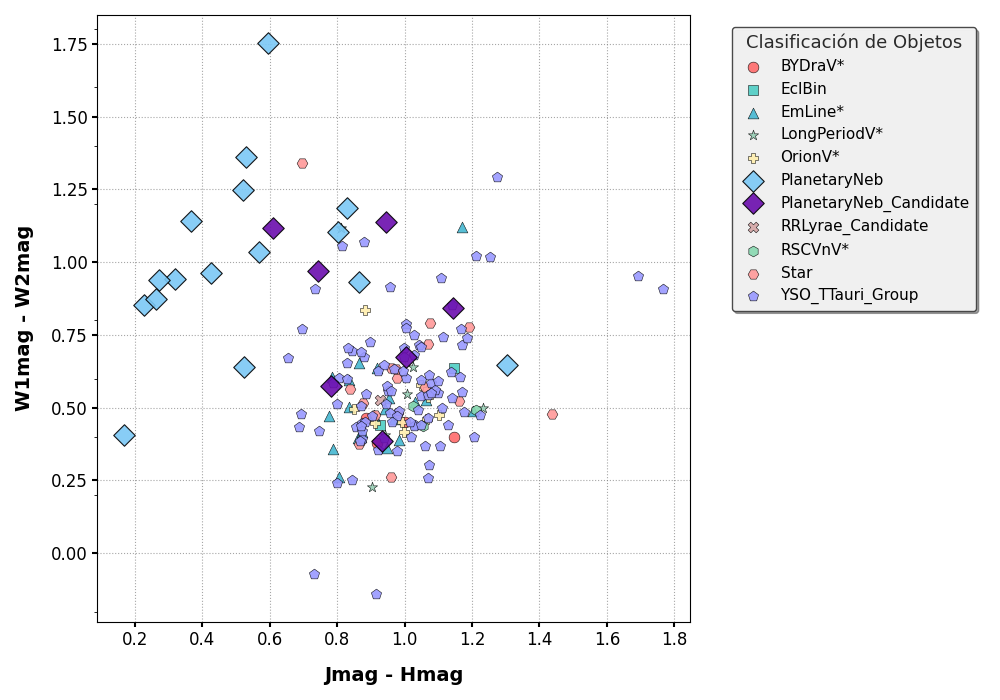

In [9]:
plot_color_color_diagram((('Jmag', 'Hmag'), ('W1mag', 'W2mag')))

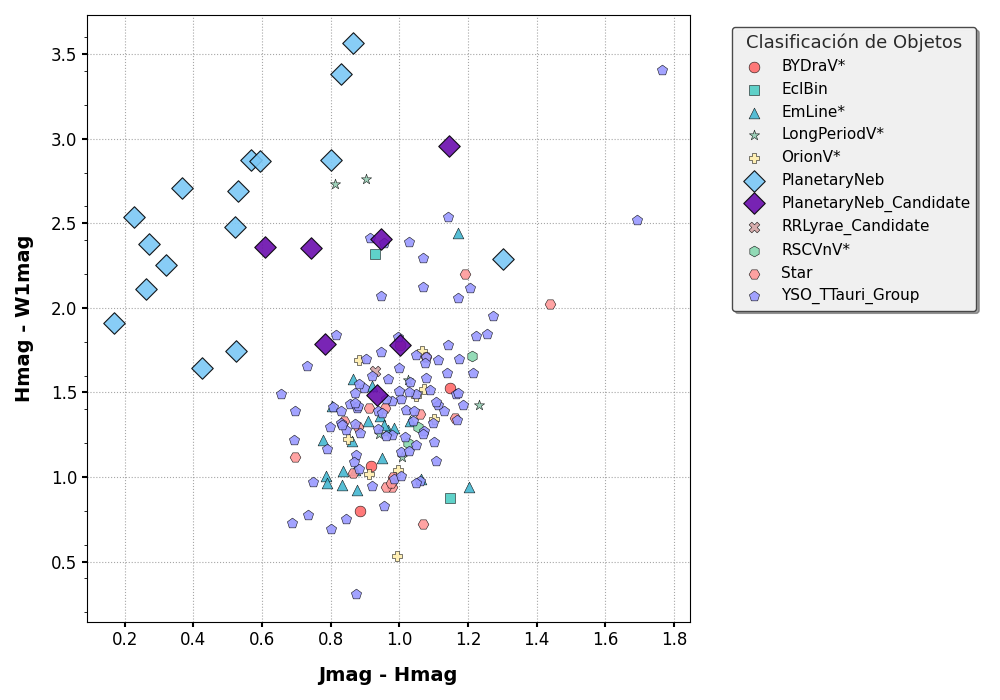

In [10]:
plot_color_color_diagram((('Jmag', 'Hmag'), ('Hmag', 'W1mag')))

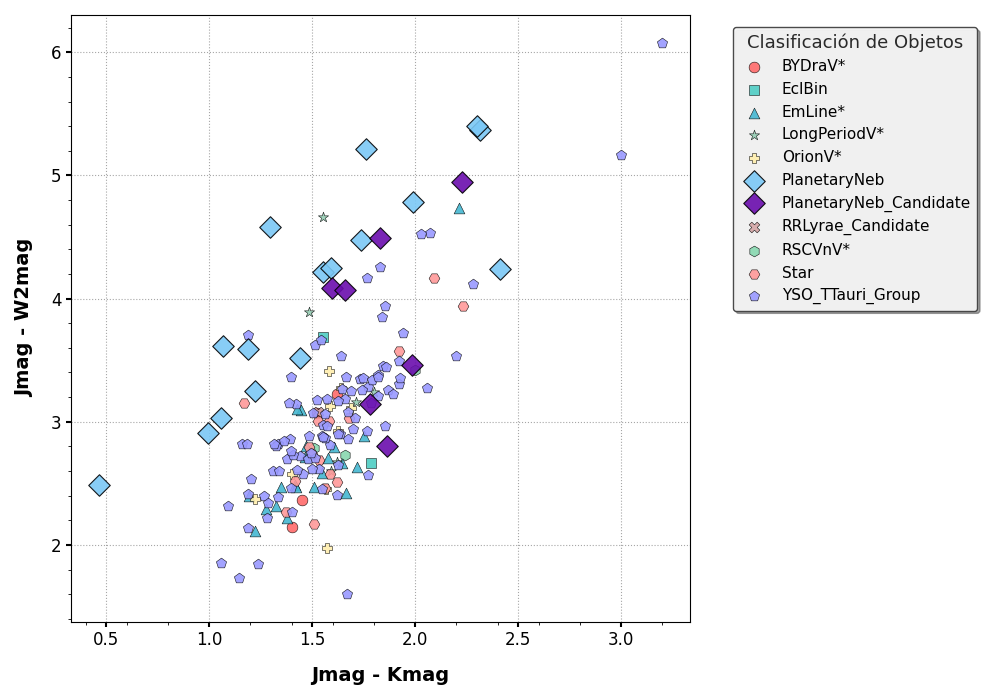

In [11]:
plot_color_color_diagram((('Jmag', 'Kmag'), ('Jmag', 'W2mag')))

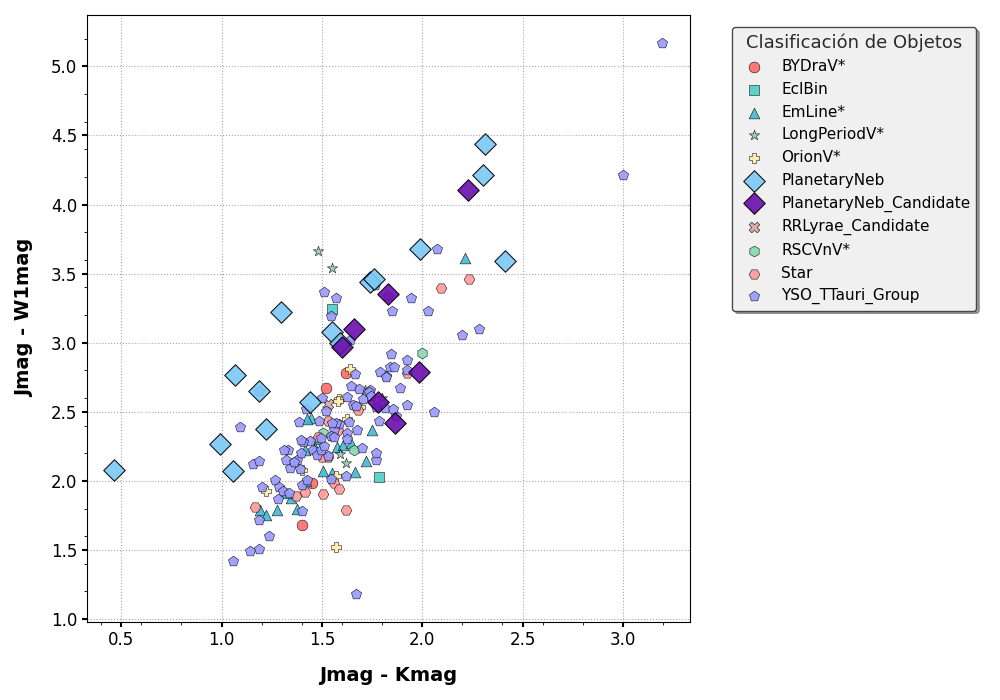

In [12]:
plot_color_color_diagram((('Jmag', 'Kmag'), ('Jmag', 'W1mag')))

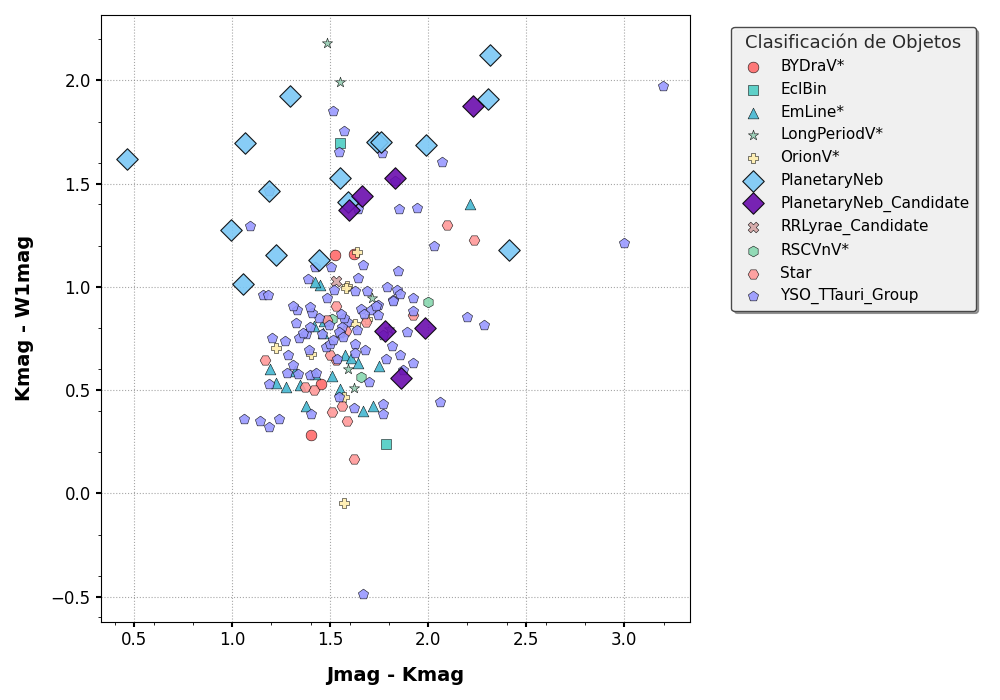

In [13]:
plot_color_color_diagram((('Jmag', 'Kmag'), ('Kmag', 'W1mag')))

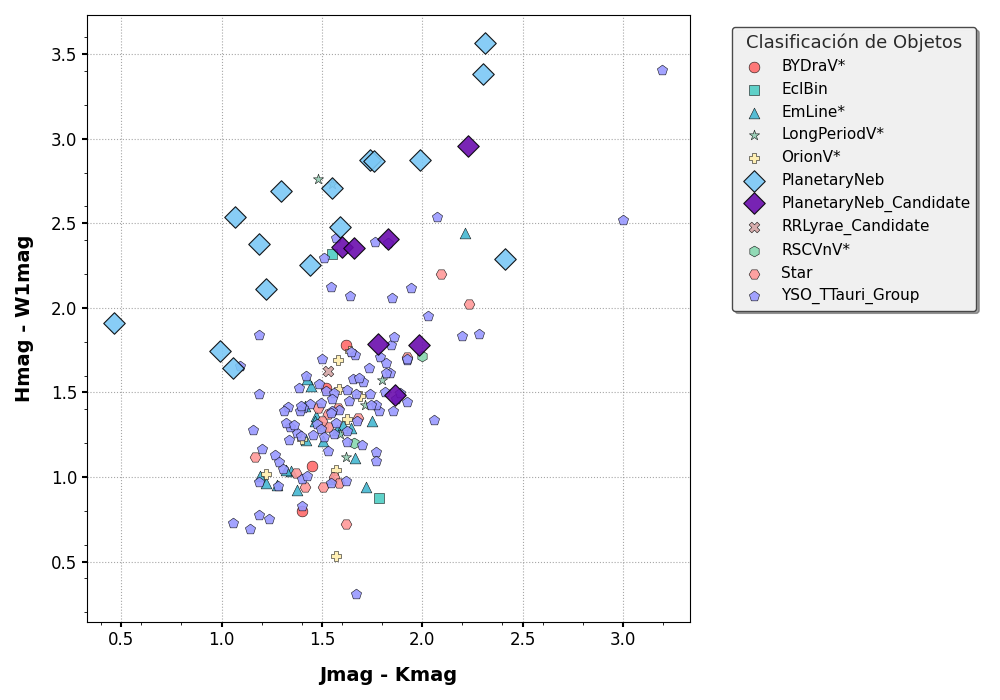

In [14]:
plot_color_color_diagram((('Jmag', 'Kmag'), ('Hmag', 'W1mag')))

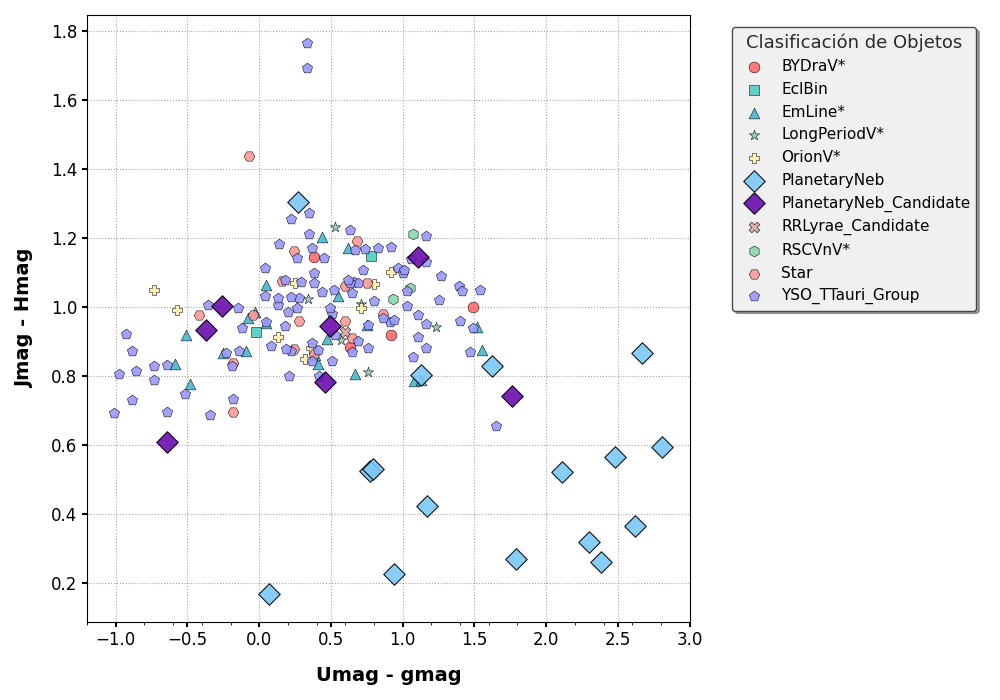

In [15]:
plot_color_color_diagram((('Umag', 'gmag'), ('Jmag', 'Hmag')))

## Documentación

### Función `open_csv_conc`

Esta función abre y concatena archivos CSV que coinciden con un patrón específico, excluyendo aquellos que contienen un patrón de exclusión en su nombre.

### Función `calculate_slope_intercept`

Esta función calcula la pendiente y el intercepto de una línea definida por dos puntos (x1, y1) y (x2, y2).

### Función `on_click_factory`

Esta función define los eventos de clic, selección, movimiento y liberación para manejar interacciones con líneas dibujadas en el gráfico.

### Función `plot_color_color_diagram`

Esta función crea un gráfico color-color para un par específico de columnas, permitiendo dibujar, mover y eliminar líneas en el gráfico.